In [6]:
import json
import argparse
from pathlib import Path
import csv
import numpy as np

import matplotlib.pyplot as plt

from skimage.draw import polygon as draw_polygon
from skimage.io import imsave

try:
    from scipy.interpolate import splprep, splev
    _has_scipy = True
except Exception:
    _has_scipy = False

In [2]:
in_path = Path("/Volumes/warm_SD/data/160/00_series/00/160_00_01_50x_patches")
out_dir = Path("/Volumes/warm_SD/data/160/00_series/00/160_00_01_50x_patches")

In [3]:
json_files = []
if in_path.is_dir():
    json_files = sorted(in_path.glob("*.json"))
elif in_path.suffix.lower() == ".json":
    json_files = [in_path]
else:
    raise SystemExit("Input must be a LabelMe JSON file or a folder of JSONs.")

if not json_files:
    raise SystemExit("No LabelMe JSON files found.")
else:
    print(f"Found {len(json_files)} *.json files")

Found 90 *.json files


In [24]:
def chaikin_smooth(points, iterations=2, closed=True):
    """
    Chaikin corner-cutting. points: (N,2) array.
    """
    pts = np.asarray(points, dtype=float)
    if closed:
        pts = np.concatenate([pts, pts[:1]], axis=0)
    for _ in range(iterations):
        Q = 0.75 * pts[:-1] + 0.25 * pts[1:]
        R = 0.25 * pts[:-1] + 0.75 * pts[1:]
        pts = np.empty((Q.shape[0] + R.shape[0], 2))
        pts[0::2] = Q
        pts[1::2] = R
        if closed:
            pts = np.concatenate([pts, pts[:1]], axis=0)
    if closed:
        return pts[:-1]
    return pts


def bspline_smooth(points, k=3, num=200, closed=True, per=True, s=0.0):
    """
    B-spline smoothing using SciPy. per=True enforces periodicity (nice for closed polygons).
    s is smoothing factor (0 = interpolating spline).
    """
    if not _has_scipy:
        raise RuntimeError("SciPy not available; install scipy or use chaikin smoothing.")
    pts = np.asarray(points, dtype=float)
    if closed:
        if not np.allclose(pts[0], pts[-1]):
            pts = np.vstack([pts, pts[0]])
    x, y = pts[:, 0], pts[:, 1]
    t = np.linspace(0, 1, len(pts))
    # Fit parametric spline
    tck, _ = splprep([x, y], u=t, s=s, per=per, k=min(k, len(pts)-1))
    unew = np.linspace(0, 1, num=num)
    out = np.vstack(splev(unew, tck)).T
    return out


def rasterize_polygon(points, height, width):
    """Return row/col indices for filled polygon inside bounds."""
    pts = np.asarray(points, dtype=float)
    rr, cc = draw_polygon(pts[:, 1], pts[:, 0], (height, width))
    return rr, cc


def to_uint_safe(max_id):
    """Pick a safe dtype for instance maps based on max instance id."""
    if max_id < 256:
        return np.uint8
    if max_id < 65536:
        return np.uint16
    return np.uint32


def convert_labelme_json(
    json_path: Path,
    out_dir: Path,
    smooth_method: str = "none",   # 'none' | 'chaikin' | 'bspline'
    smooth_iters: int = 2,         # for chaikin
    bspline_points: int = 200,     # number of points in bspline curve
    bspline_s: float = 0.0,        # smoothing factor for bspline
    include_labels: set | None = None,  # filter by label if desired
):
    data = json.loads(json_path.read_text(encoding="utf-8"))

    H = data.get("imageHeight")
    W = data.get("imageWidth")
    inst = len(data.get("shapes", []))
    print(inst)
    if H is None or W is None:
        raise ValueError(f"{json_path.name}: Missing imageHeight/imageWidth in JSON.")

    inst_map = np.zeros((H, W), dtype=np.uint32)  # large enough, cast later
    inst_map_onehot = np.zeros((inst,H,W),dtype=np.bool)
    instances = []  # list of (id, label)

    instance_id = 0
    for shp in data.get("shapes", []):
        if shp.get("shape_type", "polygon") != "polygon":
            continue  # skip non-polygons (extend here if needed)

        label = shp.get("label", "object")
        if include_labels is not None and label not in include_labels:
            continue

        pts = np.asarray(shp.get("points", []), dtype=float)
        if pts.shape[0] < 3:
            continue  # need at least a triangle

        # Smooth if requested
        if smooth_method == "chaikin":
            pts = chaikin_smooth(pts, iterations=smooth_iters, closed=True)
        elif smooth_method == "bspline":
            pts = bspline_smooth(pts, k=3, num=bspline_points, closed=True, per=True, s=bspline_s)
        # else: no smoothing

        # Clip to image bounds before rasterization (helps robustness)
        pts[:, 0] = np.clip(pts[:, 0], 0, W - 1)
        pts[:, 1] = np.clip(pts[:, 1], 0, H - 1)

        rr, cc = rasterize_polygon(pts, H, W)

        instance_id += 1
        inst_map[rr, cc] = instance_id  # later shapes overwrite earlier ones
        inst_map_onehot[instance_id-1,rr,cc] = True
        instances.append((instance_id, label))

    # Cast to compact dtype
    inst_map = inst_map.astype(to_uint_safe(int(inst_map.max())))

    # Save outputs
    stem = json_path.stem
    out_dir.mkdir(parents=True, exist_ok=True)

    np.save(out_dir / f"{stem}_instmap.npy", inst_map)
    # PNG (be mindful of dtype limits)
    imsave(out_dir / f"{stem}_instance.png", inst_map)

    # CSV mapping
    with open(out_dir / f"{stem}_instances.csv", "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["instance_id", "label"])
        writer.writerows(instances)

    return inst_map, instances, inst_map_onehot

In [ ]:
inst_map_list = []
for j in json_files[:2]:
    print(f"Processing {j.name} ...")
    inst_map, instances,inst_map_onehot = convert_labelme_json(
            j,
            out_dir=out_dir,
            smooth_method='chaikin',
            smooth_iters=6,
            # bspline_points=args.bspline_points,
            # bspline_s=args.bspline_s,
            # include_labels=include_labels,
        )
    


Processing patch_000000.json ...
81
81.0
Processing patch_000001.json ...
84
84.0


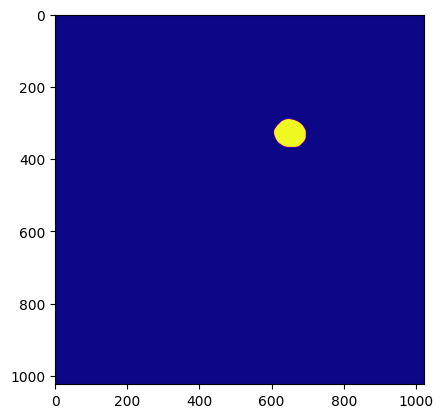

In [26]:
plt.imshow(inst_map_onehot[0,::],cmap="plasma")

In [30]:
def _iou(a, b):
    inter = np.logical_and(a, b).sum()
    if inter == 0: return 0.0
    union = np.logical_or(a, b).sum()
    return inter / union

def _bbox2d(mask_bool):
    ys, xs = np.where(mask_bool)
    if ys.size == 0:
        return [0, 0, 0, 0], [0, 0, 0, 0]
    y0, x0 = int(ys.min()), int(xs.min())
    y1, x1 = int(ys.max()) + 1, int(xs.max()) + 1
    w, h = x1 - x0, y1 - y0
    return [x0, y0, w, h], [x0, y0, x1, y1]

def _instances_from_maps(inst_map, conf_map):
    """Build SAM2-style dicts per global instance id (>0)."""
    instances = []
    ids = np.unique(inst_map)
    ids = ids[ids > 0]
    for iid in ids:
        seg = (inst_map == iid)
        area = int(seg.sum())
        if area == 0:
            continue
        bbox, crop_box = _bbox2d(seg)
        # aggregate score over pixels of this instance
        scores = conf_map[seg]
        predicted_iou = float(scores.mean()) if scores.size else 0.0
        instances.append({
            "segmentation": seg,          # (H,W) bool in global coords
            "area": area,
            "bbox": bbox,                 # [x, y, w, h] global
            "predicted_iou": predicted_iou,
            "point_coords": [],           # fill if you used prompts
            "stability_score": None,      # fill if you compute it
            "crop_box": crop_box,         # [x0, y0, x1, y1] global
        })
    return instances

def stitch_sam2_instances_with_dicts(
    padded_shape_hw, offsets, per_tile_sam2, merge_iou=0.5, debug=False
):
    """
    Inputs:
      - padded_shape_hw: (H_pad, W_pad)
      - offsets: [(y0,x0), ...] per tile (padded coords)
      - per_tile_sam2: list per tile, each a list of SAM2 dicts with keys:
           'segmentation' (HxW bool in patch coords),
           'bbox' [x,y,w,h] (patch coords),
           'predicted_iou' (float)
        (Other keys are ignored here but passed through later.)
    Returns:
      inst_map_pad, conf_map_pad, instances_list  (SAM2-style per global instance)
    """
    H, W = padded_shape_hw
    inst_map = np.zeros((H, W), dtype=np.int32)
    conf_map = np.zeros((H, W), dtype=np.float32)
    next_id = 1
    total_written = 0

    for (tile_y0, tile_x0), detections in zip(offsets, per_tile_sam2):
        for d in detections:
            # required fields
            m = d["segmentation"].astype(bool, copy=False)
            if not m.any():
                continue
            score = float(d.get("predicted_iou", 1.0))
            x, y, w, h = d.get("bbox", [0, 0, m.shape[1], m.shape[0]])
            if w == 0 or h == 0:
                # fallback to tight bbox from mask
                ys, xs = np.where(m)
                y, x = int(ys.min()), int(xs.min())
                h = int(ys.max() - y + 1)
                w = int(xs.max() - x + 1)

            by0, bx0, by1, bx1 = int(y), int(x), int(y + h), int(x + w)
            gy0, gx0 = tile_y0 + by0, tile_x0 + bx0
            gy1, gx1 = tile_y0 + by1, tile_x0 + bx1

            # bounds clamp
            gy0 = max(0, min(gy0, H)); gy1 = max(0, min(gy1, H))
            gx0 = max(0, min(gx0, W)); gx1 = max(0, min(gx1, W))
            if gy0 >= gy1 or gx0 >= gx1:
                continue

            m_sub  = m[by0:by1, bx0:bx1]
            im_sub = inst_map[gy0:gy1, gx0:gx1]
            cf_sub = conf_map[gy0:gy1, gx0:gx1]

            # find overlaps
            overlapping = np.unique(im_sub[m_sub])
            overlapping = overlapping[overlapping != 0]

            best_iou, tgt = 0.0, None
            for oid in overlapping:
                iou = _iou(m_sub, (im_sub == oid))
                if iou > best_iou:
                    best_iou, tgt = iou, oid

            if tgt is None or best_iou < merge_iou:
                tgt = next_id
                next_id += 1

            # write rule: fill empty, or replace where we’re as good or better
            write = m_sub & ((cf_sub == 0) | (score >= cf_sub))
            total_written += int(write.sum())
            im_sub[write] = tgt
            cf_sub[write] = score

            inst_map[gy0:gy1, gx0:gx1] = im_sub
            conf_map[gy0:gy1, gx0:gx1] = cf_sub

    if debug:
        print(f"[stitch] written_px={total_written}, instances={int(inst_map.max())}")

    # Build SAM2-style dicts per *global* instance from the maps:
    instances = _instances_from_maps(inst_map, conf_map)
    return inst_map, conf_map, instances
# -----------------------------------------------------------------------------